In [48]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib import rcParams
from chemevo import evolution as evo
import astropy
from astropy.table import Table

params = {
   'axes.labelsize': 15,
   'font.size': 15,
   'legend.fontsize': 14,
   'xtick.minor.visible': True,
   'ytick.minor.visible': True,
   'xtick.labelsize': 15,
   'ytick.labelsize': 15,
   'text.usetex': True, #to use TeX in your labels
   'font.family':'serif',
   'axes.titlesize': 15,
   'xtick.direction': 'in',
   'ytick.direction': 'in',
   'xtick.top': True,
   'ytick.right': True,
   'xtick.major.size': 6,
   'xtick.minor.size': 3,
   'ytick.major.size': 6,
   'ytick.minor.size': 3
   }
rcParams.update(params)

colors = ["#0072B2", "#E69F00", "#009E73", "#D55E00", "#CC79A7", "#F0E442"]
linestyles = ['-', '--', ':', '-.']

In [49]:
highalpha = pd.read_csv("../highalpha.csv")
lowalpha = pd.read_csv("../lowalpha.csv")

In [50]:
def quality_cuts(df):
        """
        Make quality cuts on the APOGEE catalog.
        Parameters
        ----------
        df : pandas.DataFrame

            Full APOGEE catalog
        Returns
        -------
        pandas.DataFrame
        """
        # Limit to main red star sample
        df = df[df['EXTRATARG'] == 0]

        # Weed out bad flags
        fatal_flags = (2**23) # STAR_BAD
        df = df[df['ASPCAPFLAG'] & fatal_flags == 0]
        # Cut low-S/N targets
        df = df[df['SNREV'] > 200]
        # Limit to giants
        df = df[(df['LOGG'] > 1) & (df['LOGG'] < 2) &
                (df['TEFF'] > 3700) & (df['TEFF'] < 4600)]
        # Replace NaN stand-in values with NaN
        df.replace(99.999, np.nan, inplace=True)
        # Limit to stars with measurements of both [Fe/H] and [O/Fe]
        df.dropna(subset=['FE_H', 'O_FE'], inplace=True)
        df.reset_index(inplace=True, drop=True)
        return df

def fits_to_pandas(path, **kwargs):
    """
    Import a table in the form of a FITS file and convert it to a pandas DataFrame.
    Parameters
    ----------
    path : Path or str
    Path to fits file
    Other keyword arguments are passed to astropy.table.Table
    Returns
    -------
    df : pandas DataFrame
    """
    # Read FITS file into astropy table
    table = Table.read(path, format='fits', **kwargs)
    # Filter out multidimensional columns
    cols = [name for name in table.colnames if len(table[name].shape) <= 1]
    # Convert byte-strings to ordinary strings and convert to pandas
    df = decode(table[cols].to_pandas())
    return df

def decode(df):
    """
    Decode DataFrame with byte strings into ordinary strings.
    Parameters
    ----------
    df : pandas DataFrame
    """
    str_df = df.select_dtypes([object])
    str_df = str_df.stack().str.decode('utf-8').unstack()
    for col in str_df:
        df[col] = str_df[col]
    return df

In [ ]:
data = fits_to_pandas("/Users/honeyeah/Codes/data/APOGEE_ASPCAP/allStarLite-dr17-synspec_rev1.fits")
data = quality_cuts(data)

data['O_H'] = data['O_FE'] + data['FE_H']
data['MG_H'] = data['MG_FE'] + data['FE_H']
data['MN_H'] = data['MN_FE'] + data['FE_H']
data['MN_O'] = data['MN_H'] - data['O_H']
data['MN_MG'] = data['MN_H'] - data['MG_H']
data['FE_MG'] = data['FE_H'] - data['MG_H']


pos_FE_H = data[(data['FE_H'] > 0)]
neg_FE_H = data[(data['FE_H'] < 0)]
data_high_alpha = pd.concat([pos_FE_H[(pos_FE_H['MG_FE'] > 0.12)], neg_FE_H[neg_FE_H['MG_FE'] > 0.12 - 0.13 * neg_FE_H['FE_H']]])
data_low_alpha = pd.concat([pos_FE_H[(pos_FE_H['MG_FE'] < 0.12)], neg_FE_H[neg_FE_H['MG_FE'] < 0.12 - 0.13 * neg_FE_H['FE_H']]])

# CONST SFR

In [52]:
t_array = np.linspace(0.0001,14,int(1e3))
dt = t_array[1] - t_array[0]
print("dt = ", dt)
tau_sfh_def = 6 #Gyrs
m_g_array_exp_def = 1 * np.exp(-t_array/tau_sfh_def)
m_g_array_const = np.ones(len(t_array))

tau_stars_2024 = [0.6, 2.0, 6.0]
etas_2024 = [0, 0.6, 2.0]

gal1 = evo.Galaxy(t_array=t_array, m_g_array=m_g_array_const, tau_star=tau_stars_2024[0], eta = etas_2024[0])
gal2 = evo.Galaxy(t_array=t_array, m_g_array=m_g_array_const, tau_star=tau_stars_2024[1], eta = etas_2024[1])
gal3 = evo.Galaxy(t_array=t_array, m_g_array=m_g_array_const, tau_star=tau_stars_2024[2], eta = etas_2024[2])

dt =  0.014013913913913914


In [53]:
mdot_star_consts = []
mstars_consts = []

for taustar in tau_stars_2024:
    mstars_consts.append(m_g_array_const/taustar * dt)


cdf_mstars_const_1 = np.cumsum(mstars_consts[0])/np.sum(mstars_consts[0])
cdf_mstars_const_2 = np.cumsum(mstars_consts[1])/np.sum(mstars_consts[1])
cdf_mstars_const_3 = np.cumsum(mstars_consts[2])/np.sum(mstars_consts[2])

Text(0.5, 0, 't (Gyrs)')

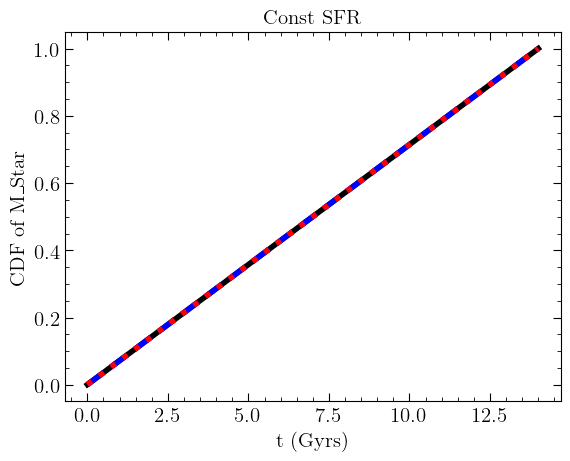

In [54]:
plt.plot(t_array, cdf_mstars_const_1, linestyle='-', lw=4, color = 'black')
plt.plot(t_array, cdf_mstars_const_2, linestyle = ':', lw=4, color = 'red', zorder=5)
plt.plot(t_array, cdf_mstars_const_3, linestyle = '--', lw=4, color = 'blue')

plt.title('Const SFR')
plt.ylabel('CDF of M_Star')
plt.xlabel('t (Gyrs)')

Text(0.5, 0, 't (Gyrs)')

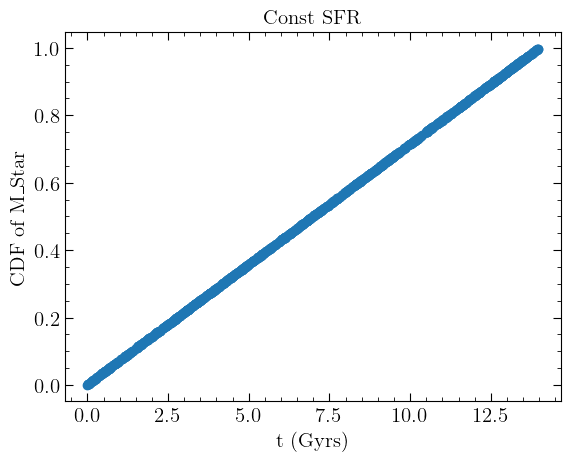

In [64]:
# 2. Define how many samples you want
n_samples = 1000
# 3. Generate uniform random numbers
u = np.random.rand(n_samples)
# 4. Perform the inverse sampling to get indices
sampled_indices_1 = np.searchsorted(cdf_mstars_const_1, u)
sampled_indices_2 = np.searchsorted(cdf_mstars_const_2, u)
sampled_indices_3 = np.searchsorted(cdf_mstars_const_3, u)

plt.scatter(t_array[sampled_indices_1], cdf_mstars_const_1[sampled_indices_1])
plt.title('Const SFR')
plt.ylabel('CDF of M_Star')
plt.xlabel('t (Gyrs)')

In [65]:
error_on_met = 0.05
gal1_df = pd.DataFrame(columns=['O_H', 'Fe_O', 'Mn_O'])
gal2_df = pd.DataFrame(columns=['O_H', 'Fe_O', 'Mn_O'])
gal3_df = pd.DataFrame(columns=['O_H', 'Fe_O', 'Mn_O'])

gal1_df['O_H'] = np.random.normal(loc=gal1.O_H[sampled_indices_1], scale = error_on_met, size=n_samples)
gal1_df['Fe_O'] = np.random.normal(loc=gal1.Fe_O[sampled_indices_1], scale = error_on_met, size=n_samples)
gal1_df['Mn_O'] = np.random.normal(loc=gal1.Mn_O[sampled_indices_1], scale = error_on_met, size=n_samples)

gal2_df['O_H'] = np.random.normal(loc=gal2.O_H[sampled_indices_2], scale = error_on_met, size=n_samples)
gal2_df['Fe_O'] = np.random.normal(loc=gal2.Fe_O[sampled_indices_2], scale = error_on_met, size=n_samples)
gal2_df['Mn_O'] = np.random.normal(loc=gal2.Mn_O[sampled_indices_2], scale = error_on_met, size=n_samples)

gal3_df['O_H'] = np.random.normal(loc=gal3.O_H[sampled_indices_3], scale = error_on_met, size=n_samples)
gal3_df['Fe_O'] = np.random.normal(loc=gal3.Fe_O[sampled_indices_3], scale = error_on_met, size=n_samples)
gal3_df['Mn_O'] = np.random.normal(loc=gal3.Mn_O[sampled_indices_3], scale = error_on_met, size=n_samples)

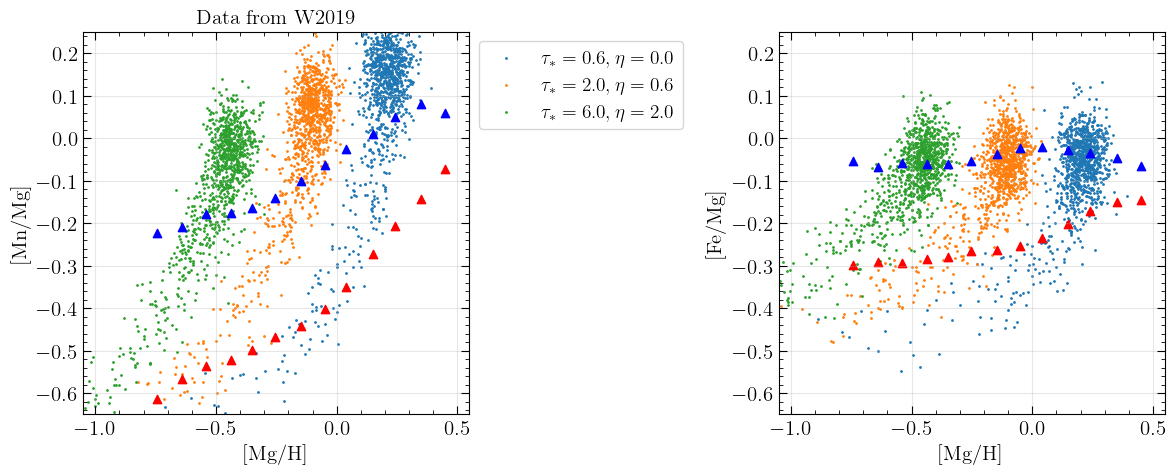

In [66]:
plt.figure(figsize=(12,5))
plt.subplot(1,2,1)
plt.scatter(highalpha['[Mg/H]'], highalpha['[Mn/Mg]'], marker='^', color = 'red', zorder=5)
plt.scatter(lowalpha['[Mg/H]'], lowalpha['[Mn/Mg]'], marker='^', color = 'blue', zorder=6)
plt.scatter(gal1_df['O_H'], gal1_df['Mn_O'], s = 1, label = rf'$\tau_* = {gal1.tau_star_arr[0]} , \eta = {gal1.eta_arr[0]} $')
plt.scatter(gal2_df['O_H'], gal2_df['Mn_O'], s = 1, label = rf'$\tau_* = {gal2.tau_star_arr[0]} , \eta = {gal2.eta_arr[0]} $')
plt.scatter(gal3_df['O_H'], gal3_df['Mn_O'], s = 1, label = rf'$\tau_* = {gal3.tau_star_arr[0]} , \eta = {gal3.eta_arr[0]} $')
#plt.scatter(data['MG_H'], data['MN_MG'], alpha = 0.1, color = 'gray')
#plt.scatter(data_low_alpha['MG_H'], data_low_alpha['MN_MG'], alpha = 0.1, color = 'cyan')
#plt.scatter(data_high_alpha['MG_H'], data_high_alpha['MN_MG'], alpha = 0.1, color = 'pink')
plt.legend(bbox_to_anchor=[1,1])
plt.grid('True', alpha = 0.3)

plt.ylim(-0.65,0.25)
plt.title('Data from W2019')
plt.xlabel('[Mg/H]')
plt.ylabel('[Mn/Mg]')
plt.xlim(-1.05,0.55)


plt.subplot(1,2,2)
#plt.scatter(data_low_alpha['MG_H'], data_low_alpha['FE_MG'], alpha = 0.1, color = 'cyan')
#plt.scatter(data_high_alpha['MG_H'], data_high_alpha['FE_MG'], alpha = 0.1, color = 'pink')
#plt.plot(gal_def_2024.O_H[10:], gal_def_2024.Fe_O[10:])
plt.scatter(gal1_df['O_H'], gal1_df['Fe_O'], s = 1)
plt.scatter(gal2_df['O_H'], gal2_df['Fe_O'], s = 1)
plt.scatter(gal3_df['O_H'], gal3_df['Fe_O'], s = 1)
plt.scatter(highalpha['[Mg/H]'], highalpha['[Fe/Mg]'], marker='^', color = 'red')
plt.scatter(lowalpha['[Mg/H]'], lowalpha['[Fe/Mg]'], marker='^', color = 'blue')
plt.grid('True', alpha = 0.3)
plt.xlabel('[Mg/H]')
plt.ylabel('[Fe/Mg]')
plt.ylim(-0.65,0.25)
plt.xlim(-1.05,0.55)
plt.tight_layout()

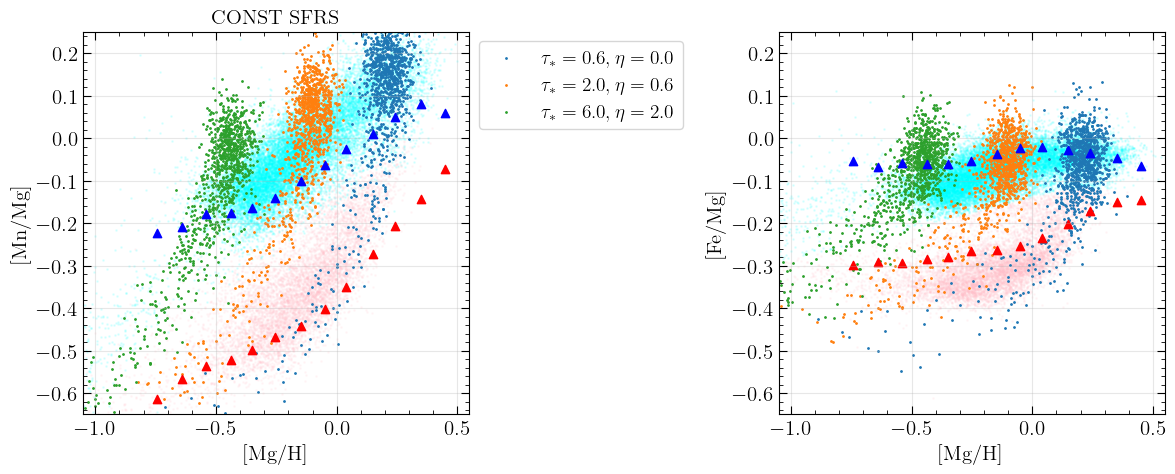

In [67]:
plt.figure(figsize=(12,5))
plt.subplot(1,2,1)
plt.scatter(data_low_alpha['MG_H'], data_low_alpha['MN_MG'], alpha = 0.1, color = 'cyan', s = 1)
plt.scatter(data_high_alpha['MG_H'], data_high_alpha['MN_MG'], alpha = 0.1, color = 'pink', s = 1)
plt.scatter(highalpha['[Mg/H]'], highalpha['[Mn/Mg]'], marker='^', color = 'red', zorder=5)
plt.scatter(lowalpha['[Mg/H]'], lowalpha['[Mn/Mg]'], marker='^', color = 'blue', zorder=6)
plt.scatter(gal1_df['O_H'], gal1_df['Mn_O'], s = 1, label = rf'$\tau_* = {gal1.tau_star_arr[0]} , \eta = {gal1.eta_arr[0]} $')
plt.scatter(gal2_df['O_H'], gal2_df['Mn_O'], s = 1, label = rf'$\tau_* = {gal2.tau_star_arr[0]} , \eta = {gal2.eta_arr[0]} $')
plt.scatter(gal3_df['O_H'], gal3_df['Mn_O'], s = 1, label = rf'$\tau_* = {gal3.tau_star_arr[0]} , \eta = {gal3.eta_arr[0]} $')
plt.legend(bbox_to_anchor=[1,1])
plt.grid('True', alpha = 0.3)

plt.ylim(-0.65,0.25)
plt.title('CONST SFRS')
plt.xlabel('[Mg/H]')
plt.ylabel('[Mn/Mg]')
plt.xlim(-1.05,0.55)


plt.subplot(1,2,2)
plt.scatter(data_low_alpha['MG_H'], data_low_alpha['FE_MG'], alpha = 0.1, color = 'cyan', s = 1)
plt.scatter(data_high_alpha['MG_H'], data_high_alpha['FE_MG'], alpha = 0.1, color = 'pink', s = 1)
plt.scatter(gal1_df['O_H'], gal1_df['Fe_O'], s = 1)
plt.scatter(gal2_df['O_H'], gal2_df['Fe_O'], s = 1)
plt.scatter(gal3_df['O_H'], gal3_df['Fe_O'], s = 1)
plt.scatter(highalpha['[Mg/H]'], highalpha['[Fe/Mg]'], marker='^', color = 'red')
plt.scatter(lowalpha['[Mg/H]'], lowalpha['[Fe/Mg]'], marker='^', color = 'blue')
plt.grid('True', alpha = 0.3)
plt.xlabel('[Mg/H]')
plt.ylabel('[Fe/Mg]')
plt.ylim(-0.65,0.25)
plt.xlim(-1.05,0.55)
plt.tight_layout()

# RISE + FALL 

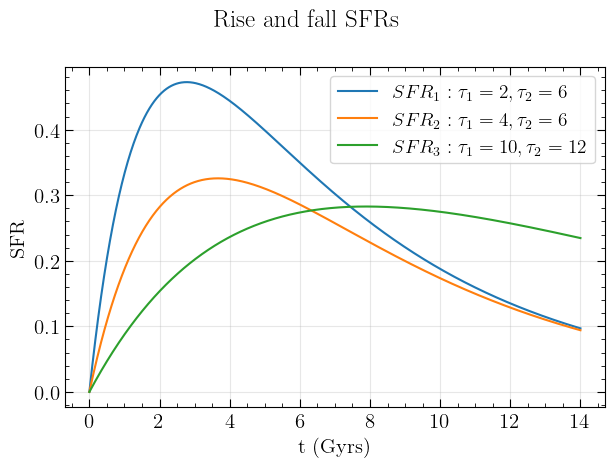

In [68]:
def rise_fall(t, tau_1, tau_2):
    return 1 * (1 - np.exp(-t/tau_1)) * np.exp(-t/tau_2)

tau_1s = [2, 4, 10]
tau_2s = [6, 6, 12]
sfr_1 = rise_fall(t_array, tau_1s[0], tau_2s[0])
sfr_2 = rise_fall(t_array, tau_1s[1], tau_2s[1])
sfr_3 = rise_fall(t_array, tau_1s[2], tau_2s[2])

plt.plot(t_array, sfr_1, label = rf'$SFR_1 : \tau_1 = {tau_1s[0]}, \tau_2 = {tau_2s[0]}$')
plt.plot(t_array, sfr_2, label = rf'$SFR_2 : \tau_1 = {tau_1s[1]}, \tau_2 = {tau_2s[1]}$')
plt.plot(t_array, sfr_3, label = rf'$SFR_3 : \tau_1 = {tau_1s[2]}, \tau_2 = {tau_2s[2]}$')

plt.grid('True', alpha = 0.3)
plt.legend()
plt.xlabel('t (Gyrs)')
plt.ylabel('SFR')

plt.suptitle("Rise and fall SFRs")
plt.tight_layout()

dt =  0.014013913913913914


Text(0.5, 0, 't (Gyrs)')

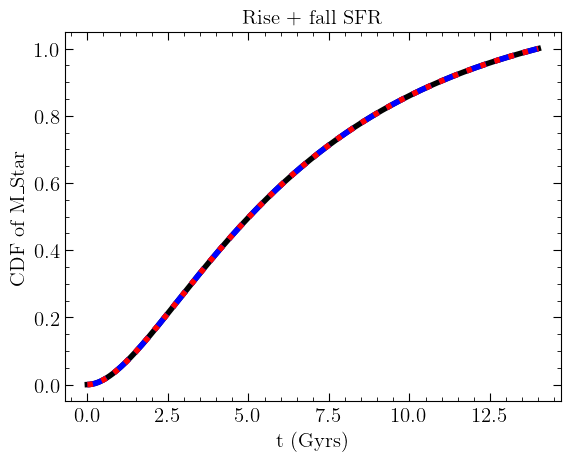

In [69]:
t_array = np.linspace(0.0001,14,int(1e3))
dt = t_array[1] - t_array[0]
print("dt = ", dt)

tau_stars_2024 = [0.6, 2.0, 6.0]
etas_2024 = [0, 0.6, 2.0]

gal1_rf = evo.Galaxy(t_array=t_array, m_g_array=sfr_1, tau_star=tau_stars_2024[0], eta = etas_2024[0])
gal2_rf = evo.Galaxy(t_array=t_array, m_g_array=sfr_2, tau_star=tau_stars_2024[1], eta = etas_2024[1])
gal3_rf = evo.Galaxy(t_array=t_array, m_g_array=sfr_3, tau_star=tau_stars_2024[2], eta = etas_2024[2])

mdot_star_consts_rf = []
mstars_consts_rf = []


mstars_rf_1 = sfr_1/tau_stars_2024[0] * dt
mstars_rf_2 = sfr_2/tau_stars_2024[1] * dt
mstars_rf_3 = sfr_3/tau_stars_2024[2] * dt


cdf_mstars_rf_1 = np.cumsum(mstars_rf_1)/np.sum(mstars_rf_1)
cdf_mstars_rf_2 = np.cumsum(mstars_rf_1)/np.sum(mstars_rf_1)
cdf_mstars_rf_3 = np.cumsum(mstars_rf_1)/np.sum(mstars_rf_1)

plt.plot(t_array, cdf_mstars_rf_1, linestyle='-', lw=4, color = 'black')
plt.plot(t_array, cdf_mstars_rf_2, linestyle = ':', lw=4, color = 'red', zorder=5)
plt.plot(t_array, cdf_mstars_rf_3, linestyle = '--', lw=4, color = 'blue')

plt.title('Rise + fall SFR')
plt.ylabel('CDF of M_Star')
plt.xlabel('t (Gyrs)')

In [76]:
# 2. Define how many samples you want
n_samples = 1000
# 3. Generate uniform random numbers
u = np.random.rand(n_samples)
# 4. Perform the inverse sampling to get indices
sampled_rfs_1 = np.searchsorted(cdf_mstars_rf_1, u)
sampled_rfs_2 = np.searchsorted(cdf_mstars_rf_2, u)
sampled_rfs_3 = np.searchsorted(cdf_mstars_rf_3, u)

error_on_met = 0.05
gal1_rf_df = pd.DataFrame(columns=['O_H', 'Fe_O', 'Mn_O', 'O_Fe', 'Fe_H'])
gal2_rf_df = pd.DataFrame(columns=['O_H', 'Fe_O', 'Mn_O', 'O_Fe', 'Fe_H'])
gal3_rf_df = pd.DataFrame(columns=['O_H', 'Fe_O', 'Mn_O', 'O_Fe', 'Fe_H'])

gal1_rf_df['O_H'] = np.random.normal(loc=gal1_rf.O_H[sampled_rfs_1], scale = error_on_met, size=n_samples)
gal1_rf_df['Fe_O'] = np.random.normal(loc=gal1_rf.Fe_O[sampled_rfs_1], scale = error_on_met, size=n_samples)
gal1_rf_df['Mn_O'] = np.random.normal(loc=gal1_rf.Mn_O[sampled_rfs_1], scale = error_on_met, size=n_samples)
gal1_rf_df['O_Fe'] = np.random.normal(loc=gal1_rf.O_Fe[sampled_rfs_1], scale = error_on_met, size=n_samples)
gal1_rf_df['Fe_H'] = np.random.normal(loc=gal1_rf.Fe_H[sampled_rfs_1], scale = error_on_met, size=n_samples)

gal2_rf_df['O_H'] = np.random.normal(loc=gal2_rf.O_H[sampled_rfs_2], scale = error_on_met, size=n_samples)
gal2_rf_df['Fe_O'] = np.random.normal(loc=gal2_rf.Fe_O[sampled_rfs_2], scale = error_on_met, size=n_samples)
gal2_rf_df['Mn_O'] = np.random.normal(loc=gal2_rf.Mn_O[sampled_rfs_2], scale = error_on_met, size=n_samples)
gal2_rf_df['O_Fe'] = np.random.normal(loc=gal2_rf.O_Fe[sampled_rfs_2], scale = error_on_met, size=n_samples)
gal2_rf_df['Fe_H'] = np.random.normal(loc=gal2_rf.Fe_H[sampled_rfs_2], scale = error_on_met, size=n_samples)

gal3_rf_df['O_H'] = np.random.normal(loc=gal3_rf.O_H[sampled_rfs_3], scale = error_on_met, size=n_samples)
gal3_rf_df['Fe_O'] = np.random.normal(loc=gal3_rf.Fe_O[sampled_rfs_3], scale = error_on_met, size=n_samples)
gal3_rf_df['Mn_O'] = np.random.normal(loc=gal3_rf.Mn_O[sampled_rfs_3], scale = error_on_met, size=n_samples)
gal3_rf_df['O_Fe'] = np.random.normal(loc=gal3_rf.O_Fe[sampled_rfs_3], scale = error_on_met, size=n_samples)
gal3_rf_df['Fe_H'] = np.random.normal(loc=gal3_rf.Fe_H[sampled_rfs_3], scale = error_on_met, size=n_samples)


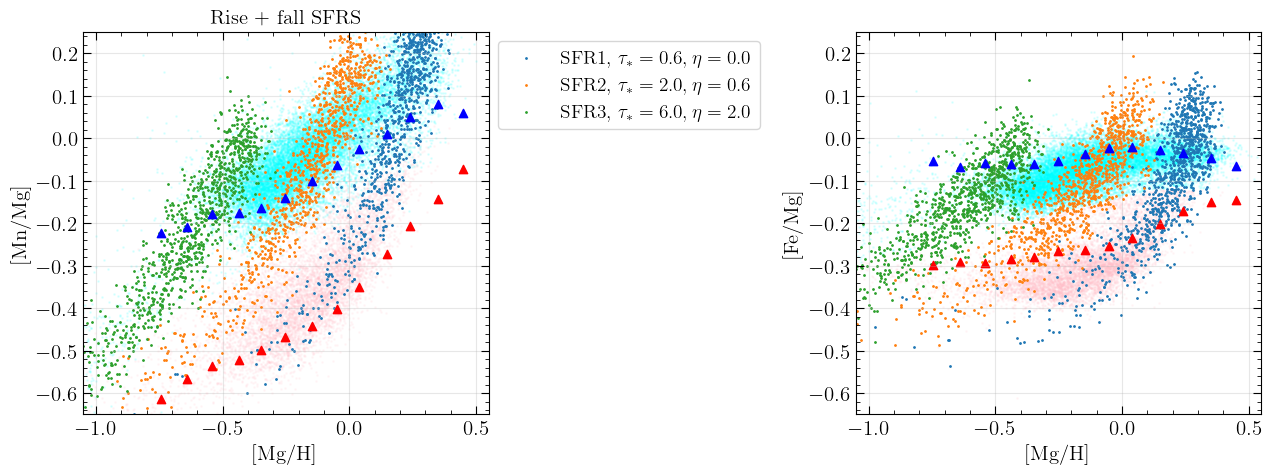

In [71]:
plt.figure(figsize=(13,5))
plt.subplot(1,2,1)
plt.scatter(data_low_alpha['MG_H'], data_low_alpha['MN_MG'], alpha = 0.1, color = 'cyan', s = 1)
plt.scatter(data_high_alpha['MG_H'], data_high_alpha['MN_MG'], alpha = 0.1, color = 'pink', s = 1)
plt.scatter(highalpha['[Mg/H]'], highalpha['[Mn/Mg]'], marker='^', color = 'red', zorder=5)
plt.scatter(lowalpha['[Mg/H]'], lowalpha['[Mn/Mg]'], marker='^', color = 'blue', zorder=6)
plt.scatter(gal1_rf_df['O_H'], gal1_rf_df['Mn_O'], s = 1, label = rf'SFR1, $\tau_* = {gal1_rf.tau_star_arr[0]} , \eta = {gal1_rf.eta_arr[0]} $')
plt.scatter(gal2_rf_df['O_H'], gal2_rf_df['Mn_O'], s = 1, label = rf'SFR2, $\tau_* = {gal2_rf.tau_star_arr[0]} , \eta = {gal2_rf.eta_arr[0]} $')
plt.scatter(gal3_rf_df['O_H'], gal3_rf_df['Mn_O'], s = 1, label = rf'SFR3, $\tau_* = {gal3_rf.tau_star_arr[0]} , \eta = {gal3_rf.eta_arr[0]} $')


plt.legend(bbox_to_anchor=[1,1])
plt.grid('True', alpha = 0.3)

plt.ylim(-0.65,0.25)
plt.title('Rise + fall SFRS')
plt.xlabel('[Mg/H]')
plt.ylabel('[Mn/Mg]')
plt.xlim(-1.05,0.55)


plt.subplot(1,2,2)
plt.scatter(data_low_alpha['MG_H'], data_low_alpha['FE_MG'], alpha = 0.1, color = 'cyan', s = 1)
plt.scatter(data_high_alpha['MG_H'], data_high_alpha['FE_MG'], alpha = 0.1, color = 'pink', s = 1)
plt.scatter(gal1_rf_df['O_H'], gal1_rf_df['Fe_O'], s = 1)
plt.scatter(gal2_rf_df['O_H'], gal2_rf_df['Fe_O'], s = 1)
plt.scatter(gal3_rf_df['O_H'], gal3_rf_df['Fe_O'], s = 1)


plt.scatter(highalpha['[Mg/H]'], highalpha['[Fe/Mg]'], marker='^', color = 'red')
plt.scatter(lowalpha['[Mg/H]'], lowalpha['[Fe/Mg]'], marker='^', color = 'blue')
plt.grid('True', alpha = 0.3)
plt.xlabel('[Mg/H]')
plt.ylabel('[Fe/Mg]')
plt.ylim(-0.65,0.25)
plt.xlim(-1.05,0.55)
plt.tight_layout()

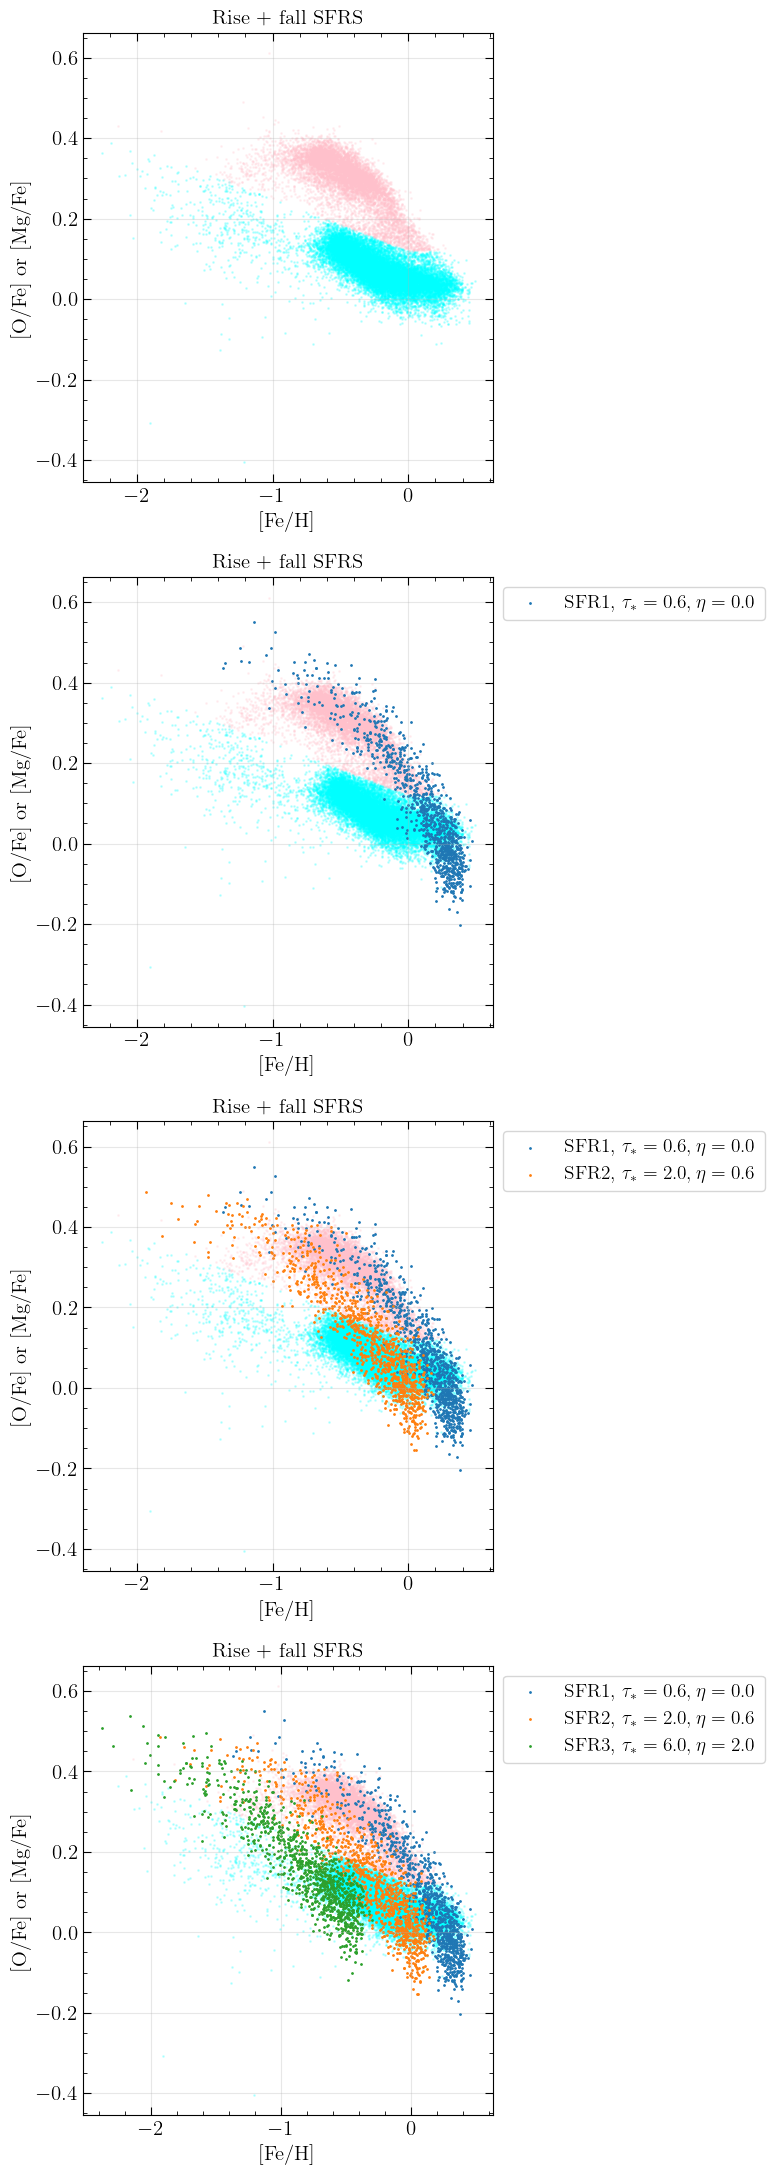

In [92]:
plt.figure(figsize=(8,22))
plt.subplot(4,1,1)
plt.scatter(data_low_alpha['FE_H'], data_low_alpha['MG_FE'], alpha = 0.2, color = 'cyan', s = 1)
plt.scatter(data_high_alpha['FE_H'], data_high_alpha['MG_FE'], alpha = 0.2, color = 'pink', s = 1)
#plt.scatter(highalpha['[Mg/H]'], highalpha['[Mn/Mg]'], marker='^', color = 'red', zorder=5)
#plt.scatter(lowalpha['[Mg/H]'], lowalpha['[Mn/Mg]'], marker='^', color = 'blue', zorder=6)
#plt.scatter(gal1_rf_df['Fe_H'], gal1_rf_df['O_Fe'], s = 1, label = rf'SFR1, $\tau_* = {gal1_rf.tau_star_arr[0]} , \eta = {gal1_rf.eta_arr[0]} $')
#plt.scatter(gal2_rf_df['Fe_H'], gal2_rf_df['O_Fe'], s = 1, label = rf'SFR2, $\tau_* = {gal2_rf.tau_star_arr[0]} , \eta = {gal2_rf.eta_arr[0]} $')
#plt.scatter(gal3_rf_df['Fe_H'], gal3_rf_df['O_Fe'], s = 1, label = rf'SFR3, $\tau_* = {gal3_rf.tau_star_arr[0]} , \eta = {gal3_rf.eta_arr[0]} $')
#plt.legend(bbox_to_anchor=[1,1])
plt.grid('True', alpha = 0.3)
#plt.ylim(-0.65,0.25)
plt.title('Rise + fall SFRS')
plt.xlabel('[Fe/H]')
plt.ylabel('[O/Fe] or [Mg/Fe]')
#plt.xlim(-1.05,0.55)

plt.subplot(4,1,2)
plt.scatter(data_low_alpha['FE_H'], data_low_alpha['MG_FE'], alpha = 0.2, color = 'cyan', s = 1)
plt.scatter(data_high_alpha['FE_H'], data_high_alpha['MG_FE'], alpha = 0.2, color = 'pink', s = 1)
#plt.scatter(highalpha['[Mg/H]'], highalpha['[Mn/Mg]'], marker='^', color = 'red', zorder=5)
#plt.scatter(lowalpha['[Mg/H]'], lowalpha['[Mn/Mg]'], marker='^', color = 'blue', zorder=6)
plt.scatter(gal1_rf_df['Fe_H'], gal1_rf_df['O_Fe'], s = 1, label = rf'SFR1, $\tau_* = {gal1_rf.tau_star_arr[0]} , \eta = {gal1_rf.eta_arr[0]} $')
#plt.scatter(gal2_rf_df['Fe_H'], gal2_rf_df['O_Fe'], s = 1, label = rf'SFR2, $\tau_* = {gal2_rf.tau_star_arr[0]} , \eta = {gal2_rf.eta_arr[0]} $')
#plt.scatter(gal3_rf_df['Fe_H'], gal3_rf_df['O_Fe'], s = 1, label = rf'SFR3, $\tau_* = {gal3_rf.tau_star_arr[0]} , \eta = {gal3_rf.eta_arr[0]} $')
plt.legend(bbox_to_anchor=[1,1])
plt.grid('True', alpha = 0.3)
#plt.ylim(-0.65,0.25)
plt.title('Rise + fall SFRS')
plt.xlabel('[Fe/H]')
plt.ylabel('[O/Fe] or [Mg/Fe]')
#plt.xlim(-1.05,0.55)

plt.subplot(4,1,3)
plt.scatter(data_low_alpha['FE_H'], data_low_alpha['MG_FE'], alpha = 0.2, color = 'cyan', s = 1)
plt.scatter(data_high_alpha['FE_H'], data_high_alpha['MG_FE'], alpha = 0.2, color = 'pink', s = 1)
#plt.scatter(highalpha['[Mg/H]'], highalpha['[Mn/Mg]'], marker='^', color = 'red', zorder=5)
#plt.scatter(lowalpha['[Mg/H]'], lowalpha['[Mn/Mg]'], marker='^', color = 'blue', zorder=6)
plt.scatter(gal1_rf_df['Fe_H'], gal1_rf_df['O_Fe'], s = 1, label = rf'SFR1, $\tau_* = {gal1_rf.tau_star_arr[0]} , \eta = {gal1_rf.eta_arr[0]} $')
plt.scatter(gal2_rf_df['Fe_H'], gal2_rf_df['O_Fe'], s = 1, label = rf'SFR2, $\tau_* = {gal2_rf.tau_star_arr[0]} , \eta = {gal2_rf.eta_arr[0]} $')
#plt.scatter(gal3_rf_df['Fe_H'], gal3_rf_df['O_Fe'], s = 1, label = rf'SFR3, $\tau_* = {gal3_rf.tau_star_arr[0]} , \eta = {gal3_rf.eta_arr[0]} $')
plt.legend(bbox_to_anchor=[1,1])
plt.grid('True', alpha = 0.3)
#plt.ylim(-0.65,0.25)
plt.title('Rise + fall SFRS')
plt.xlabel('[Fe/H]')
plt.ylabel('[O/Fe] or [Mg/Fe]')
#plt.xlim(-1.05,0.55)

plt.subplot(4,1,4)
plt.scatter(data_low_alpha['FE_H'], data_low_alpha['MG_FE'], alpha = 0.2, color = 'cyan', s = 1)
plt.scatter(data_high_alpha['FE_H'], data_high_alpha['MG_FE'], alpha = 0.2, color = 'pink', s = 1)
#plt.scatter(highalpha['[Mg/H]'], highalpha['[Mn/Mg]'], marker='^', color = 'red', zorder=5)
#plt.scatter(lowalpha['[Mg/H]'], lowalpha['[Mn/Mg]'], marker='^', color = 'blue', zorder=6)
plt.scatter(gal1_rf_df['Fe_H'], gal1_rf_df['O_Fe'], s = 1, label = rf'SFR1, $\tau_* = {gal1_rf.tau_star_arr[0]} , \eta = {gal1_rf.eta_arr[0]} $')
plt.scatter(gal2_rf_df['Fe_H'], gal2_rf_df['O_Fe'], s = 1, label = rf'SFR2, $\tau_* = {gal2_rf.tau_star_arr[0]} , \eta = {gal2_rf.eta_arr[0]} $')
plt.scatter(gal3_rf_df['Fe_H'], gal3_rf_df['O_Fe'], s = 1, label = rf'SFR3, $\tau_* = {gal3_rf.tau_star_arr[0]} , \eta = {gal3_rf.eta_arr[0]} $')
plt.legend(bbox_to_anchor=[1,1])
plt.grid('True', alpha = 0.3)
#plt.ylim(-0.65,0.25)
plt.title('Rise + fall SFRS')
plt.xlabel('[Fe/H]')
plt.ylabel('[O/Fe] or [Mg/Fe]')
#plt.xlim(-1.05,0.55)


plt.tight_layout()

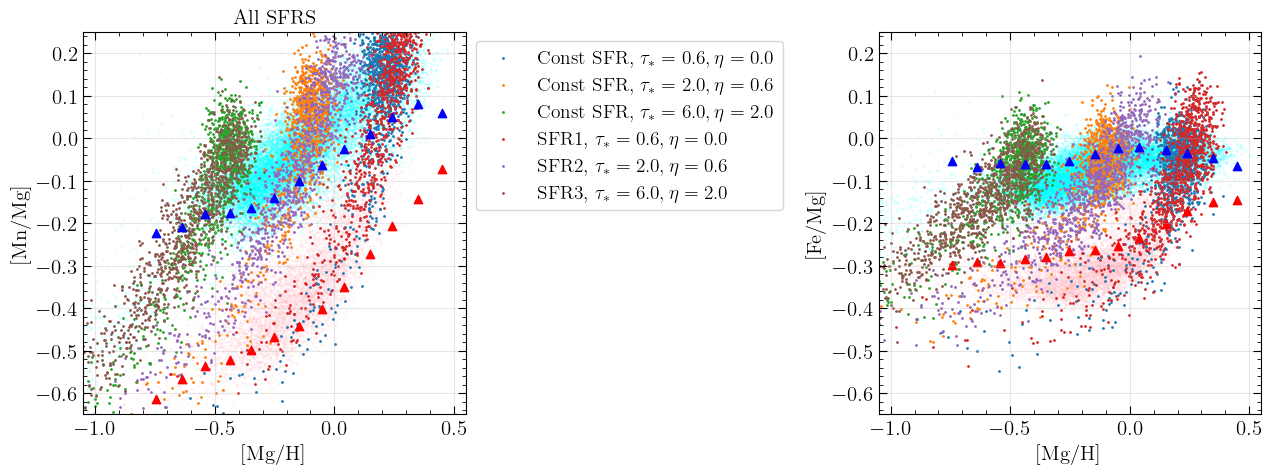

In [72]:
plt.figure(figsize=(13,5))
plt.subplot(1,2,1)
plt.scatter(data_low_alpha['MG_H'], data_low_alpha['MN_MG'], alpha = 0.1, color = 'cyan', s = 1)
plt.scatter(data_high_alpha['MG_H'], data_high_alpha['MN_MG'], alpha = 0.1, color = 'pink', s = 1)
plt.scatter(highalpha['[Mg/H]'], highalpha['[Mn/Mg]'], marker='^', color = 'red', zorder=5)
plt.scatter(lowalpha['[Mg/H]'], lowalpha['[Mn/Mg]'], marker='^', color = 'blue', zorder=6)
plt.scatter(gal1_df['O_H'], gal1_df['Mn_O'], s = 1, label = rf'Const SFR, $\tau_* = {gal1.tau_star_arr[0]} , \eta = {gal1.eta_arr[0]} $')
plt.scatter(gal2_df['O_H'], gal2_df['Mn_O'], s = 1, label = rf'Const SFR, $\tau_* = {gal2.tau_star_arr[0]} , \eta = {gal2.eta_arr[0]} $')
plt.scatter(gal3_df['O_H'], gal3_df['Mn_O'], s = 1, label = rf'Const SFR, $\tau_* = {gal3.tau_star_arr[0]} , \eta = {gal3.eta_arr[0]} $')

plt.scatter(gal1_rf_df['O_H'], gal1_rf_df['Mn_O'], s = 1, label = rf'SFR1, $\tau_* = {gal1_rf.tau_star_arr[0]} , \eta = {gal1_rf.eta_arr[0]} $')
plt.scatter(gal2_rf_df['O_H'], gal2_rf_df['Mn_O'], s = 1, label = rf'SFR2, $\tau_* = {gal2_rf.tau_star_arr[0]} , \eta = {gal2_rf.eta_arr[0]} $')
plt.scatter(gal3_rf_df['O_H'], gal3_rf_df['Mn_O'], s = 1, label = rf'SFR3, $\tau_* = {gal3_rf.tau_star_arr[0]} , \eta = {gal3_rf.eta_arr[0]} $')


plt.legend(bbox_to_anchor=[1,1])
plt.grid('True', alpha = 0.3)

plt.ylim(-0.65,0.25)
plt.title('All SFRS')
plt.xlabel('[Mg/H]')
plt.ylabel('[Mn/Mg]')
plt.xlim(-1.05,0.55)


plt.subplot(1,2,2)
plt.scatter(data_low_alpha['MG_H'], data_low_alpha['FE_MG'], alpha = 0.1, color = 'cyan', s = 1)
plt.scatter(data_high_alpha['MG_H'], data_high_alpha['FE_MG'], alpha = 0.1, color = 'pink', s = 1)
plt.scatter(gal1_df['O_H'], gal1_df['Fe_O'], s = 1)
plt.scatter(gal2_df['O_H'], gal2_df['Fe_O'], s = 1)
plt.scatter(gal3_df['O_H'], gal3_df['Fe_O'], s = 1)

plt.scatter(gal1_rf_df['O_H'], gal1_rf_df['Fe_O'], s = 1)
plt.scatter(gal2_rf_df['O_H'], gal2_rf_df['Fe_O'], s = 1)
plt.scatter(gal3_rf_df['O_H'], gal3_rf_df['Fe_O'], s = 1)


plt.scatter(highalpha['[Mg/H]'], highalpha['[Fe/Mg]'], marker='^', color = 'red')
plt.scatter(lowalpha['[Mg/H]'], lowalpha['[Fe/Mg]'], marker='^', color = 'blue')
plt.grid('True', alpha = 0.3)
plt.xlabel('[Mg/H]')
plt.ylabel('[Fe/Mg]')
plt.ylim(-0.65,0.25)
plt.xlim(-1.05,0.55)
plt.tight_layout()